## House Price Prediction Using Advanced Regression Techniques

#### Importing libraries and loading data

In [7]:
! pip install xgboost

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [9]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


#### Checking the data

In [10]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [12]:
sample_submission.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

#### Checking the target column

In [14]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

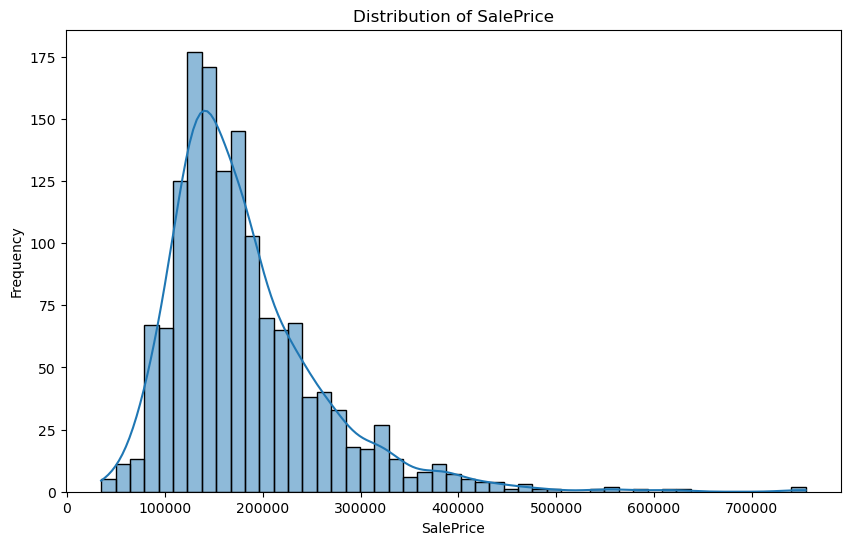

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

#### Separating features and target

In [16]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

test_ids = test["Id"]

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", test.shape)

X shape: (1460, 80)
y shape: (1460,)
Test shape: (1459, 80)


#### Combining train and test for preprocessing

In [18]:
combined = pd.concat([X, test], axis=0)

print("Combined shape:", combined.shape)

Combined shape: (2919, 80)


#### Droping Id

In [19]:
combined = combined.drop("Id", axis=1)

#### Handle missing values

In [20]:
numeric_cols = combined.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = combined.select_dtypes(include=["object"]).columns

print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 36
Categorical columns: 43


In [21]:
# Fill missing values for numerical values with median
combined[numeric_cols] = combined[numeric_cols].fillna(combined[numeric_cols].median())

In [22]:
# Fill missing values for categorical columns with mode
for col in categorical_cols:
    combined[col] = combined[col].fillna(combined[col].mode()[0])

In [23]:
# check missing values
combined.isnull().sum().sum()

0

#### Encoding categorical columns

In [24]:
combined_encoded = pd.get_dummies(combined, drop_first=True)

print("Encoded shape:", combined_encoded.shape)

Encoded shape: (2919, 244)


#### Spliting back into train and test

In [25]:
X_processed = combined_encoded.iloc[:len(train), :]
test_processed = combined_encoded.iloc[len(train):, :]

print("Processed training data:", X_processed.shape)
print("Processed test data:", test_processed.shape)

Processed training data: (1460, 244)
Processed test data: (1459, 244)


#### Log-transform target

In [26]:
y_log = np.log1p(y)

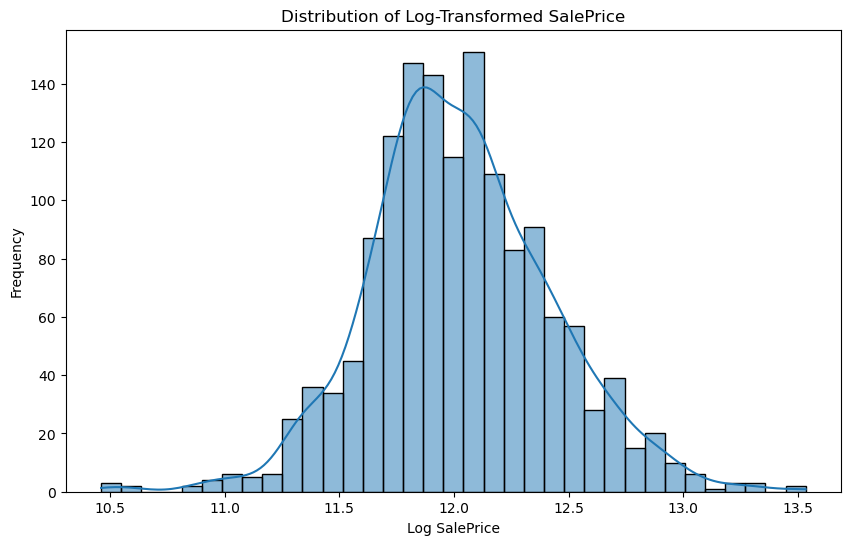

In [27]:
# comparing before and after:
plt.figure(figsize=(10, 6))
sns.histplot(y_log, kde=True)
plt.title("Distribution of Log-Transformed SalePrice")
plt.xlabel("Log SalePrice")
plt.ylabel("Frequency")
plt.show()

#### Train/validation split

In [28]:
X_train, X_valid, y_train_log, y_valid_log = train_test_split(
    X_processed,
    y_log,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (1168, 244)
Validation set: (292, 244)


#### Model 1: Linear Regression

In [29]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train_log)

linear_pred_log = linear_model.predict(X_valid)

linear_rmse = np.sqrt(mean_squared_error(y_valid_log, linear_pred_log))

linear_pred_actual = np.expm1(linear_pred_log)
y_valid_actual = np.expm1(y_valid_log)

linear_mae = mean_absolute_error(y_valid_actual, linear_pred_actual)
linear_r2 = r2_score(y_valid_actual, linear_pred_actual)

print("Linear Regression Results")
print("RMSE Log:", linear_rmse)
print("MAE Actual Price:", linear_mae)
print("R2 Score:", linear_r2)

Linear Regression Results
RMSE Log: 0.21550445761806783
MAE Actual Price: 15324.851727135476
R2 Score: 0.9143459607571324


In [30]:
print(X_processed.shape)
print(test_processed.shape)
print(y_log.shape)
print(X_train.shape)
print(X_valid.shape)
print(y_train_log.shape)
print(y_valid_log.shape)

(1460, 244)
(1459, 244)
(1460,)
(1168, 244)
(292, 244)
(1168,)
(292,)


#### Model 2: Ridge Regression

In [31]:
ridge_model = Ridge(alpha=10)

ridge_model.fit(X_train, y_train_log)

ridge_pred_log = ridge_model.predict(X_valid)

ridge_rmse = np.sqrt(mean_squared_error(y_valid_log, ridge_pred_log))

ridge_pred_actual = np.expm1(ridge_pred_log)

ridge_mae = mean_absolute_error(y_valid_actual, ridge_pred_actual)
ridge_r2 = r2_score(y_valid_actual, ridge_pred_actual)

print("Ridge Regression Results")
print("RMSE Log:", ridge_rmse)
print("MAE Actual Price:", ridge_mae)
print("R2 Score:", ridge_r2)

Ridge Regression Results
RMSE Log: 0.1383939341841014
MAE Actual Price: 16509.266777485227
R2 Score: 0.9168024530475164


#### Model 3: Random Forest Regressor

In [32]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_log)

rf_pred_log = rf_model.predict(X_valid)

rf_rmse = np.sqrt(mean_squared_error(y_valid_log, rf_pred_log))

rf_pred_actual = np.expm1(rf_pred_log)

rf_mae = mean_absolute_error(y_valid_actual, rf_pred_actual)
rf_r2 = r2_score(y_valid_actual, rf_pred_actual)

print("Random Forest Regressor Results")
print("RMSE Log:", rf_rmse)
print("MAE Actual Price:", rf_mae)
print("R2 Score:", rf_r2)

Random Forest Regressor Results
RMSE Log: 0.14749211631803813
MAE Actual Price: 17522.152799988628
R2 Score: 0.8881575418696342


#### Model 4: Gradient Boosting Regressor

In [33]:
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train_log)

gb_pred_log = gb_model.predict(X_valid)

gb_rmse = np.sqrt(mean_squared_error(y_valid_log, gb_pred_log))

gb_pred_actual = np.expm1(gb_pred_log)

gb_mae = mean_absolute_error(y_valid_actual, gb_pred_actual)
gb_r2 = r2_score(y_valid_actual, gb_pred_actual)

print("Gradient Boosting Regressor Results")
print("RMSE Log:", gb_rmse)
print("MAE Actual Price:", gb_mae)
print("R2 Score:", gb_r2)

Gradient Boosting Regressor Results
RMSE Log: 0.14042287199466733
MAE Actual Price: 17038.428840989054
R2 Score: 0.8685203630801923


#### Model 5: HistGradientBoosting Regressor

In [34]:
hist_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    random_state=42
)

hist_model.fit(X_train, y_train_log)

hist_pred_log = hist_model.predict(X_valid)

hist_rmse = np.sqrt(mean_squared_error(y_valid_log, hist_pred_log))

hist_pred_actual = np.expm1(hist_pred_log)

hist_mae = mean_absolute_error(y_valid_actual, hist_pred_actual)
hist_r2 = r2_score(y_valid_actual, hist_pred_actual)

print("HistGradientBoosting Regressor Results")
print("RMSE Log:", hist_rmse)
print("MAE Actual Price:", hist_mae)
print("R2 Score:", hist_r2)

HistGradientBoosting Regressor Results
RMSE Log: 0.13826076418209446
MAE Actual Price: 16406.861379708433
R2 Score: 0.8937977355931358


#### Model 6: XGBoost Regressor

##### training the model:

In [35]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train_log)

xgb_pred_log = xgb_model.predict(X_valid)

xgb_rmse = np.sqrt(mean_squared_error(y_valid_log, xgb_pred_log))

xgb_pred_actual = np.expm1(xgb_pred_log)

xgb_mae = mean_absolute_error(y_valid_actual, xgb_pred_actual)
xgb_r2 = r2_score(y_valid_actual, xgb_pred_actual)

print("XGBoost Regressor Results")
print("RMSE Log:", xgb_rmse)
print("MAE Actual Price:", xgb_mae)
print("R2 Score:", xgb_r2)

XGBoost Regressor Results
RMSE Log: 0.13031766709724807
MAE Actual Price: 15511.999224101037
R2 Score: 0.9063615240409805


### Comparing all models

In [36]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "HistGradientBoosting Regressor",
        "XGBoost Regressor"
    ],
    "RMSE Log": [
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse,
        hist_rmse,
        xgb_rmse
    ],
    "MAE Actual Price": [
        linear_mae,
        ridge_mae,
        rf_mae,
        gb_mae,
        hist_mae,
        xgb_mae
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2,
        rf_r2,
        gb_r2,
        hist_r2,
        xgb_r2
    ]
})

results_df = results_df.sort_values(by="RMSE Log")

results_df

,Model,RMSE Log,MAE Actual Price,R2 Score
5,XGBoost Regressor,0.130318,15511.999224,0.906362
4,HistGradientBoosting Regressor,0.138261,16406.861380,0.893798
1,Ridge Regression,0.138394,16509.266777,0.916802
3,Gradient Boosting Regressor,0.140423,17038.428841,0.868520
2,Random Forest Regressor,0.147492,17522.152800,0.888158
0,Linear Regression,0.215504,15324.851727,0.914346


In [38]:
# Sort all models from best to worst based on RMSE Log
sorted_results = results_df.sort_values(by="RMSE Log", ascending=True).reset_index(drop=True)

sorted_results

,Model,RMSE Log,MAE Actual Price,R2 Score
0,XGBoost Regressor,0.130318,15511.999224,0.906362
1,HistGradientBoosting Regressor,0.138261,16406.861380,0.893798
2,Ridge Regression,0.138394,16509.266777,0.916802
3,Gradient Boosting Regressor,0.140423,17038.428841,0.868520
4,Random Forest Regressor,0.147492,17522.152800,0.888158
5,Linear Regression,0.215504,15324.851727,0.914346


In [39]:
best_model_name = sorted_results.iloc[0]["Model"]
best_rmse = sorted_results.iloc[0]["RMSE Log"]

print("Best Model:", best_model_name)
print("Best RMSE Log:", best_rmse)

Best Model: XGBoost Regressor
Best RMSE Log: 0.13031766709724807


#### Actual vs Predicted graph for XGBoost

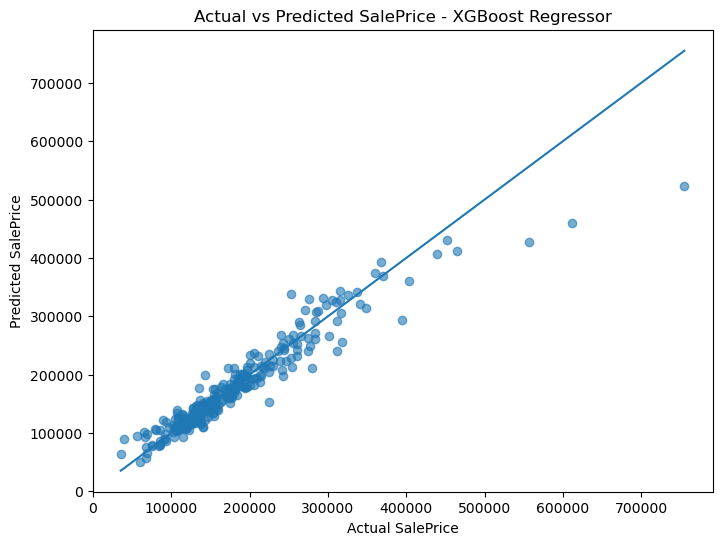

In [40]:
# Actual vs Predicted values for XGBoost

plt.figure(figsize=(8, 6))

plt.scatter(y_valid_actual, xgb_pred_actual, alpha=0.6)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice - XGBoost Regressor")

# Perfect prediction reference line
min_price = min(y_valid_actual.min(), xgb_pred_actual.min())
max_price = max(y_valid_actual.max(), xgb_pred_actual.max())

plt.plot([min_price, max_price], [min_price, max_price])

plt.show()

#### Residual plot for XGBoost

Residual = Actual Price - Predicted Price

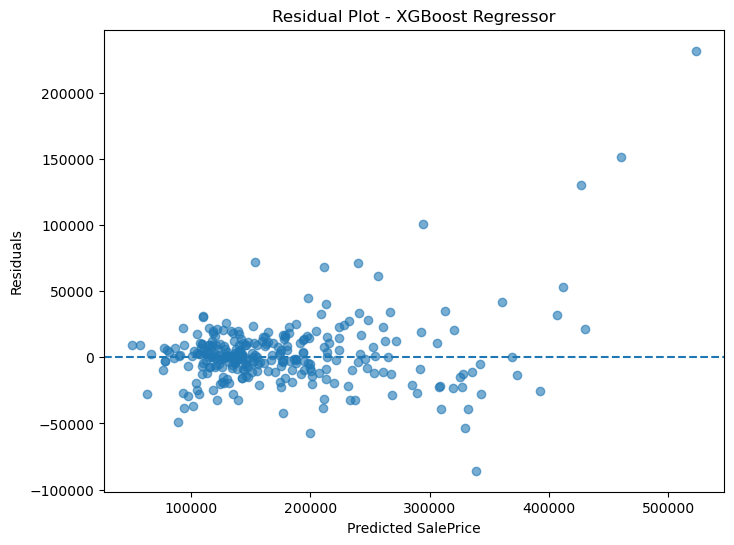

In [41]:
# Calculate residuals
residuals = y_valid_actual - xgb_pred_actual

plt.figure(figsize=(8, 6))

plt.scatter(xgb_pred_actual, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residual Plot - XGBoost Regressor")

plt.show()

#### Error distribution graph

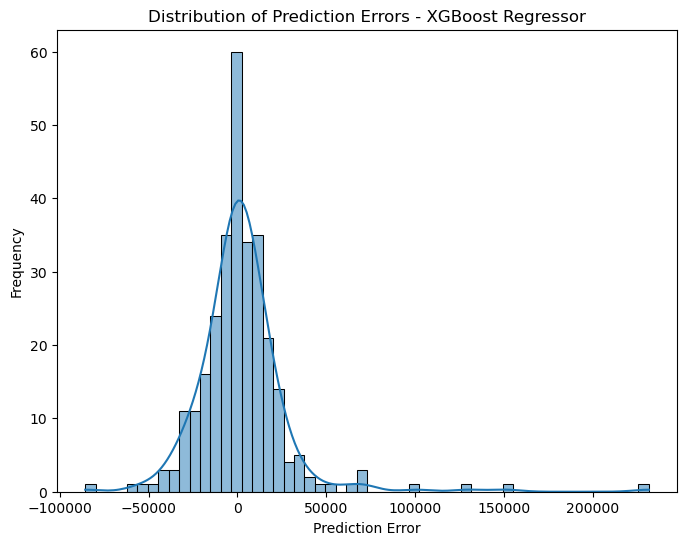

In [42]:
# Distribution of prediction errors

plt.figure(figsize=(8, 6))

sns.histplot(residuals, kde=True)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors - XGBoost Regressor")

plt.show()

#### Model comparison graph using RMSE Log

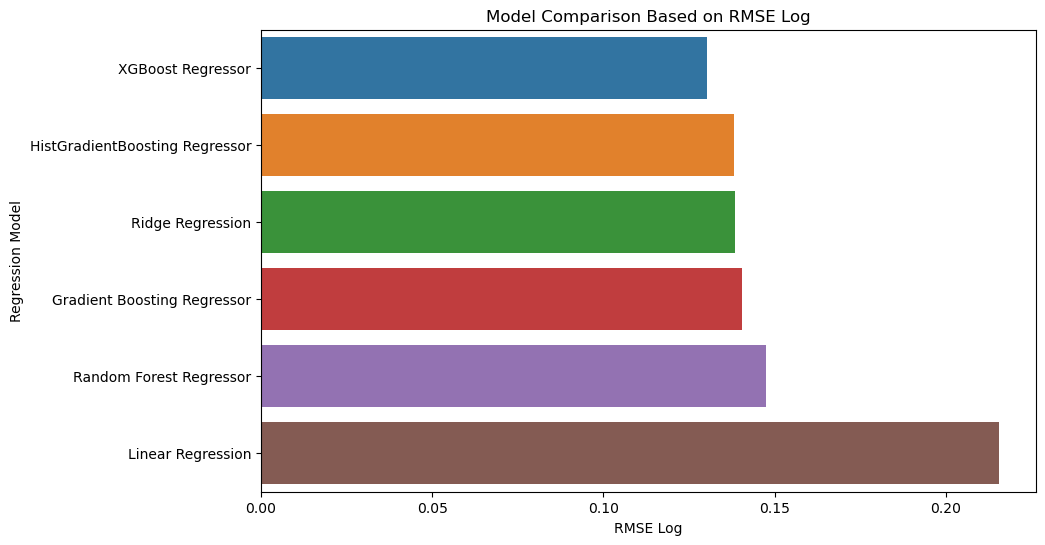

In [43]:
# Model comparison graph

plt.figure(figsize=(10, 6))

sns.barplot(
    x="RMSE Log",
    y="Model",
    data=sorted_results
)

plt.title("Model Comparison Based on RMSE Log")
plt.xlabel("RMSE Log")
plt.ylabel("Regression Model")

plt.show()

#### Model comparison graph using R2 Score

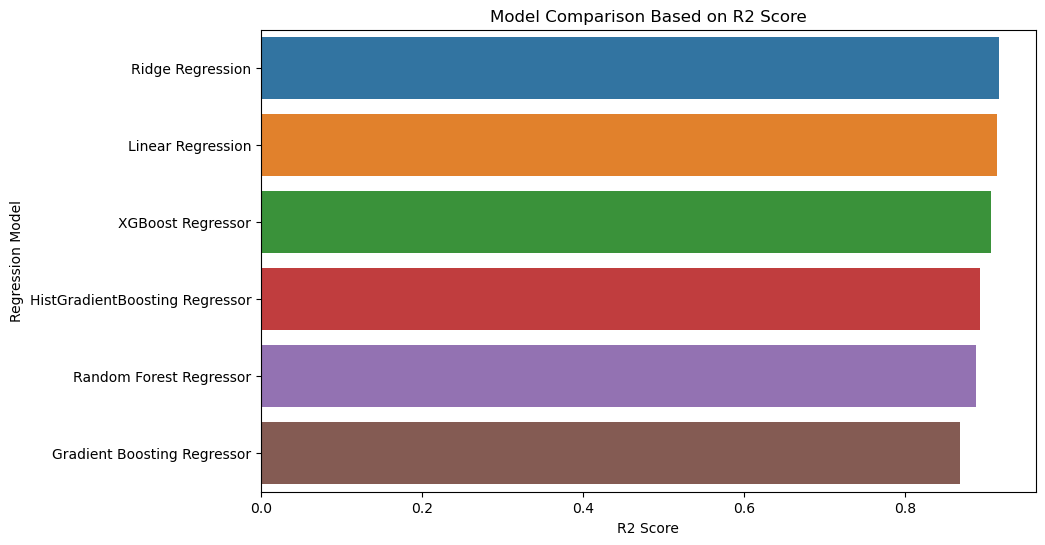

In [44]:
# Model comparison using R2 Score

r2_sorted = results_df.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="R2 Score",
    y="Model",
    data=r2_sorted
)

plt.title("Model Comparison Based on R2 Score")
plt.xlabel("R2 Score")
plt.ylabel("Regression Model")

plt.show()

#### Feature importance graph for XGBoost

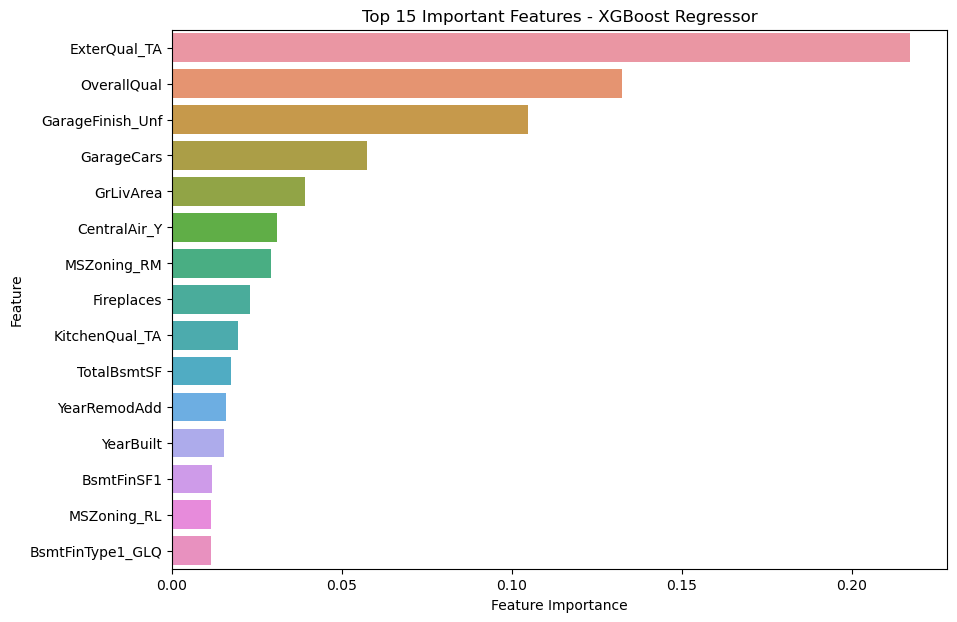

In [45]:
# Feature importance for XGBoost

feature_importance = pd.DataFrame({
    "Feature": X_processed.columns,
    "Importance": xgb_model.feature_importances_
})

top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 15 Important Features - XGBoost Regressor")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

#### Test the model with some validation predictions

In [46]:
# Create a table of actual vs predicted prices

prediction_test = pd.DataFrame({
    "Actual SalePrice": y_valid_actual,
    "Predicted SalePrice": xgb_pred_actual,
    "Error": y_valid_actual - xgb_pred_actual,
    "Absolute Error": abs(y_valid_actual - xgb_pred_actual)
})

prediction_test.head(10)

,Actual SalePrice,Predicted SalePrice,Error,Absolute Error
892,154500.0,143656.718750,10843.281250,10843.281250
1105,325000.0,335744.187500,-10744.187500,10744.187500
413,115000.0,112566.203125,2433.796875,2433.796875
522,159000.0,147799.093750,11200.906250,11200.906250
1036,315500.0,327961.656250,-12461.656250,12461.656250
614,75500.0,78549.703125,-3049.703125,3049.703125
218,311500.0,239897.890625,71602.109375,71602.109375
1160,146000.0,140782.234375,5217.765625,5217.765625
649,84500.0,77305.125000,7194.875000,7194.875000
887,135500.0,136471.359375,-971.359375,971.359375


In [47]:
prediction_test.head(10).round(2)

,Actual SalePrice,Predicted SalePrice,Error,Absolute Error
892,154500.0,143656.718750,10843.28,10843.28
1105,325000.0,335744.187500,-10744.19,10744.19
413,115000.0,112566.203125,2433.80,2433.80
522,159000.0,147799.093750,11200.91,11200.91
1036,315500.0,327961.656250,-12461.66,12461.66
614,75500.0,78549.703125,-3049.70,3049.70
218,311500.0,239897.906250,71602.11,71602.11
1160,146000.0,140782.234375,5217.77,5217.77
649,84500.0,77305.117188,7194.87,7194.87
887,135500.0,136471.359375,-971.36,971.36


#### Final prediction code for Kaggle test.csv

In [48]:
# Train XGBoost on the full training dataset

final_xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

final_xgb_model.fit(X_processed, y_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [49]:
# Predict test.csv SalePrice values

test_predictions_log = final_xgb_model.predict(test_processed)

test_predictions = np.expm1(test_predictions_log)

In [50]:
# Create submission file for Kaggle

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_predictions
})

submission.head()

,Id,SalePrice
0,1461,122700.664062
1,1462,156226.609375
2,1463,183340.937500
3,1464,190857.656250
4,1465,189787.500000


In [51]:
submission.to_csv("submission.csv", index=False)

#### Checking predicted prices

In [52]:
submission["SalePrice"].describe()

count      1459.000000
mean     176976.000000
std       75444.937500
min       45208.425781
25%      127192.785156
50%      156622.375000
75%      207897.992188
max      522144.156250
Name: SalePrice, dtype: float64

#### ploting predicted prices:

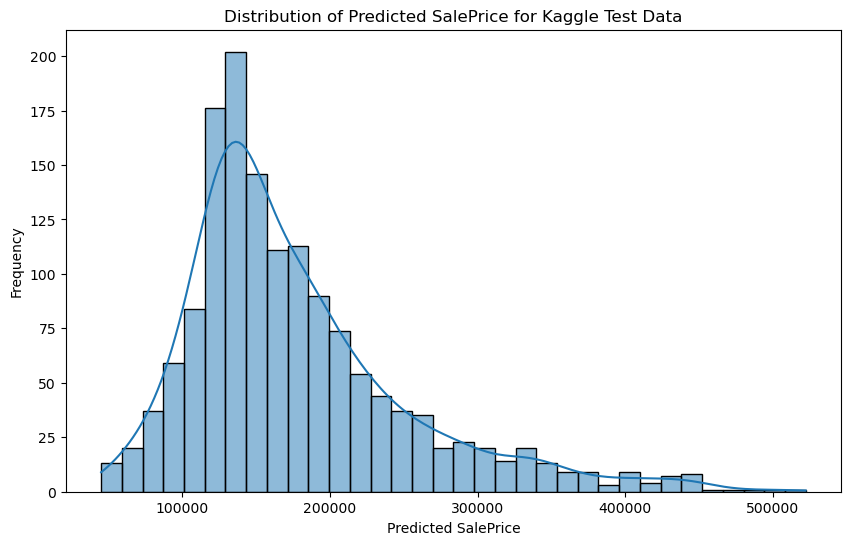

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(submission["SalePrice"], kde=True)

plt.title("Distribution of Predicted SalePrice for Kaggle Test Data")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Frequency")

plt.show()